In [2]:
import pandas as pd
import numpy as np
import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter
import os

In [3]:
os.getcwd()

'C:\\Users\\pc\\Dropbox\\School\\UBC\\Co-op\\ICORD\\Kramer-Lab---Modelling-Sham-tcSCS'

In [4]:
# loading csv's into a dict of dataframes.

from pathlib import Path
import pandas as pd

def load_j_field_stats(folder="Mask_Filter_J_Field"):
    """
    Load CSVs in `folder` that:
      - end with 'J_Field_Statistics.csv'
      - do NOT contain 'Lower_Limbs' in the filename

    Returns
    -------
    dict[str, pd.DataFrame]
        Keys are electrode configs parsed from filenames, e.g.
        'DM-C_J_Field_Statistics.csv' -> {'DM-C': DataFrame}
    """
    folder_path = Path(folder)
    data_dict: dict[str, pd.DataFrame] = {}

    if not folder_path.exists():
        raise FileNotFoundError(f"Folder not found: {folder_path.resolve()}")

    # Iterate through CSV files only
    for csv_path in folder_path.glob("*.csv"):
        stem = csv_path.stem  # filename without .csv

        # Exclude files containing "Lower_Limbs"
        if "Lower_Limbs" in stem:
            continue

        # Keep only files ending in "J_Field_Statistics"
        if not stem.endswith("J_Field_Statistics"):
            continue

        # Extract electrode config key (everything before suffix)
        # Example: "DM-C_J_Field_Statistics" -> "DM-C"
        key = stem[: -len("_J_Field_Statistics")]

        # Load CSV into DataFrame
        df = pd.read_csv(csv_path)

        # Store in dict (warn on duplicate keys)
        if key in data_dict:
            print(f"Warning: duplicate key '{key}' found. Overwriting with: {csv_path.name}")

        data_dict[key] = df

    return data_dict


# --- Usage ---
j_field_dfs = load_j_field_stats("Mask_Filter_J_Field")

# Inspect what was loaded
print("Loaded keys:", list(j_field_dfs.keys()))

# Example access
# print(j_field_dfs["DM-C"].head())

Loaded keys: ['DM-C', 'DM-R', 'DO-C', 'DO-I', 'DV-I', 'DV-PI', 'DV-PU', 'DV-U']


In [11]:
# loading csv's into a dict of dataframes.

from pathlib import Path
import pandas as pd

def load_j_field_stats(folder="Mask_Filter_J_Field"):
    """
    Load CSVs in `folder` that:
      - end with 'J_Field_Statistics.csv'
      - do NOT contain 'Lower_Limbs' in the filename

    Returns
    -------
    dict[str, pd.DataFrame]
        Keys are electrode configs parsed from filenames, e.g.
        'DM-C_J_Field_Statistics.csv' -> {'DM-C': DataFrame}
    """
    folder_path = Path(folder)
    data_dict: dict[str, pd.DataFrame] = {}

    if not folder_path.exists():
        raise FileNotFoundError(f"Folder not found: {folder_path.resolve()}")

    # Iterate through CSV files only
    for csv_path in folder_path.glob("*.csv"):
        stem = csv_path.stem  # filename without .csv

        # Exclude files containing "Lower_Limbs"
        if "Lower_Limbs" not in stem:
            continue

        # Keep only files ending in "J_Field_Statistics"
        if not stem.endswith("J_Field_Statistics"):
            continue

        # Extract electrode config key (everything before suffix)
        # Example: "DM-C_J_Field_Statistics" -> "DM-C"
        key = stem[: -len("_Lower_Limbs_J_Field_Statistics")]

        # Load CSV into DataFrame
        df = pd.read_csv(csv_path)

        # Store in dict (warn on duplicate keys)
        if key in data_dict:
            print(f"Warning: duplicate key '{key}' found. Overwriting with: {csv_path.name}")

        data_dict[key] = df

    return data_dict


# --- Usage ---
lower_limb_j_field_dfs = load_j_field_stats("Mask_Filter_J_Field")

# Inspect what was loaded
print("Loaded keys:", list(lower_limb_j_field_dfs.keys()))

# Example access
# print(j_field_dfs["DM-C"].head())

Loaded keys: ['DM-C', 'DM-R', 'DO-C', 'DO-I', 'DV-I', 'DV-PI', 'DV-PU', 'DV-U']


In [6]:
j_field_dfs['DM-C']

,Unnamed: 0,Name,Tissue,Min,Max,Average,Integral
0,0,DM-C,Total,0.000141,34.190052,1.253212,0.000458
1,1,DM-C,CSF,0.001927,34.190052,2.838723,0.000428
2,2,DM-C,Dura Mater,0.000141,6.197234,0.054212,0.000010
3,3,DM-C,White Matter,0.020518,5.633023,0.541261,0.000015
4,4,DM-C,Grey Matter,0.032775,5.515463,0.676747,0.000006


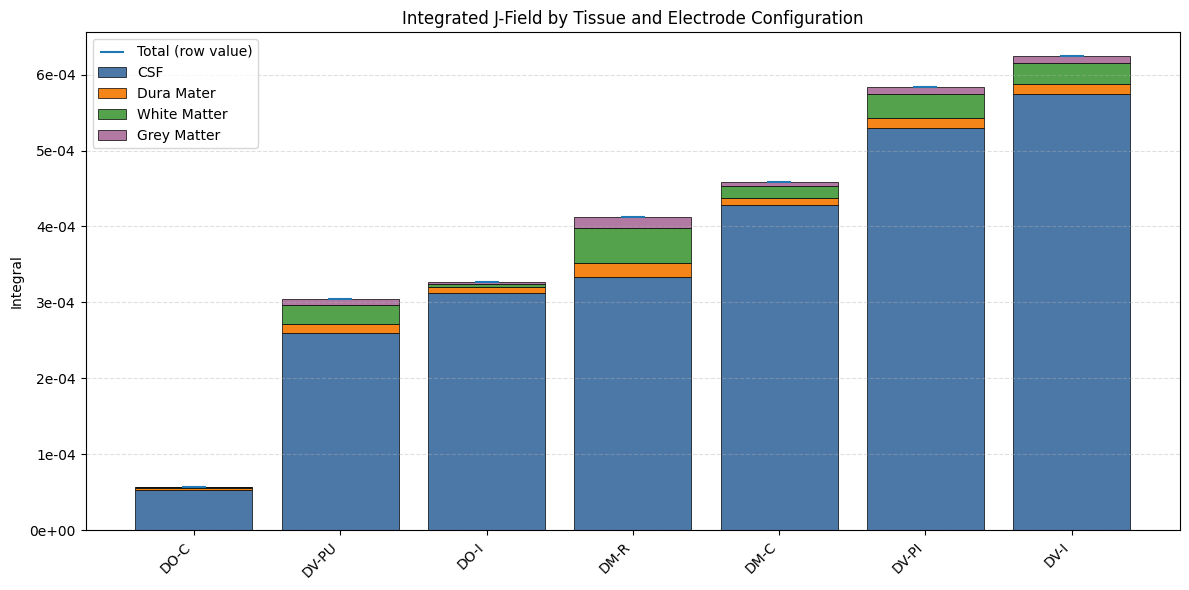


Skipped entries:
  - DV-U: missing columns: ['Tissue', 'Integral']


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

def plot_stacked_jfield_integrals(
    j_field_dfs: dict[str, pd.DataFrame],
    order: list[str] | None = None,
    integral_col: str = "Integral",
    tissue_col: str = "Tissue",
    config_col: str = "Name",
    title: str = "Integrated J-Field by Tissue and Electrode Configuration",
    figsize=(12, 6),
    annotate_total=False,
    rescale_segments_to_total=True,
):
    """
    Plot one stacked vertical bar chart from a dict of J-field statistics DataFrames.

    Each bar = one electrode config (dict key)
    Bar height = 'Total' row in Integral column
    Stacked segments = Integral values for:
        - CSF
        - Dura Mater
        - White Matter
        - Grey Matter

    Parameters
    ----------
    j_field_dfs : dict[str, pd.DataFrame]
        Dictionary of DataFrames keyed by electrode config (e.g., 'DM-C').
    order : list[str] | None
        Optional plotting order for keys. If None, uses sorted keys.
    integral_col : str
        Column containing integrated values.
    tissue_col : str
        Column containing tissue labels.
    config_col : str
        Column containing config name (not required if using dict keys, but kept for flexibility).
    title : str
        Plot title.
    figsize : tuple
        Figure size.
    annotate_total : bool
        If True, annotate each bar with total Integral value.
    rescale_segments_to_total : bool
        If True, rescales the 4 tissue segment values so they sum exactly to the 'Total' value.
        Useful if there are tiny rounding mismatches.
    """

    tissue_order = ["CSF", "Dura Mater", "White Matter", "Grey Matter"]

    # Use a fixed color mapping for consistency
    colors = {
        "CSF": "#4C78A8",
        "Dura Mater": "#F58518",
        "White Matter": "#54A24B",
        "Grey Matter": "#B279A2",
    }

    # Decide plotting order
    keys = order if order is not None else sorted(j_field_dfs.keys())

    if order is None:
        keys = sorted(
            keys,
            key=lambda k: pd.to_numeric(
                j_field_dfs[k].loc[
                    j_field_dfs[k][tissue_col].astype(str).str.strip().str.lower() == "total",
                    integral_col
                ],
                errors="coerce"
            ).iloc[0]
            if (
                k in j_field_dfs
                and tissue_col in j_field_dfs[k].columns
                and integral_col in j_field_dfs[k].columns
                and not j_field_dfs[k].loc[
                    j_field_dfs[k][tissue_col].astype(str).str.strip().str.lower() == "total",
                    integral_col
                ].empty
            )
            else np.inf
        )

    # Storage for plotting values
    totals = []
    stacked_vals = {t: [] for t in tissue_order}

    # Track issues
    skipped = []
    mismatch_info = []

    for key in keys:
        if key not in j_field_dfs:
            skipped.append((key, "missing from j_field_dfs"))
            continue

        df = j_field_dfs[key].copy()

        # Basic column checks
        required_cols = [tissue_col, integral_col]
        missing_cols = [c for c in required_cols if c not in df.columns]
        if missing_cols:
            skipped.append((key, f"missing columns: {missing_cols}"))
            continue

        # Clean tissue labels + integral values
        df[tissue_col] = df[tissue_col].astype(str).str.strip()
        df[integral_col] = pd.to_numeric(df[integral_col], errors="coerce")

        # Get Total integral
        total_match = df.loc[df[tissue_col].str.lower() == "total", integral_col]
        if total_match.empty:
            skipped.append((key, "no 'Total' row found"))
            continue

        total_val = float(total_match.iloc[0])

        # Get tissue integrals
        seg_vals = []
        missing_tissues = []
        for tissue in tissue_order:
            match = df.loc[df[tissue_col].str.lower() == tissue.lower(), integral_col]
            if match.empty:
                missing_tissues.append(tissue)
                seg_vals.append(np.nan)
            else:
                seg_vals.append(float(match.iloc[0]))

        if missing_tissues:
            skipped.append((key, f"missing tissue rows: {missing_tissues}"))
            continue

        seg_sum = float(np.nansum(seg_vals))

        # Optionally rescale so stacked bar sums exactly to Total
        if rescale_segments_to_total and np.isfinite(seg_sum) and seg_sum != 0:
            if not np.isclose(seg_sum, total_val, rtol=1e-6, atol=1e-12):
                mismatch_info.append((key, total_val, seg_sum))
            scale = total_val / seg_sum
            seg_vals = [v * scale for v in seg_vals]
        else:
            if not np.isclose(seg_sum, total_val, rtol=1e-6, atol=1e-12):
                mismatch_info.append((key, total_val, seg_sum))

        totals.append(total_val)
        for tissue, v in zip(tissue_order, seg_vals):
            stacked_vals[tissue].append(v)

    # If nothing valid, stop
    if len(totals) == 0:
        raise ValueError("No valid DataFrames found to plot. Check schema/row labels.")

    # Keep only keys successfully processed
    valid_keys = [k for k in keys if k not in [s[0] for s in skipped]]

    # Plot
    x = np.arange(len(valid_keys))
    fig, ax = plt.subplots(figsize=figsize)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0e'))

    bottom = np.zeros(len(valid_keys), dtype=float)
    for tissue in tissue_order:
        vals = np.array(stacked_vals[tissue], dtype=float)
        ax.bar(
            x,
            vals,
            bottom=bottom,
            label=tissue,
            color=colors.get(tissue, None),
            edgecolor="black",
            linewidth=0.5,
        )
        bottom += vals

    # Optional total markers (shows exact total even if tiny mismatch exists)
    ax.scatter(x, totals, marker="_", s=300, linewidths=1.5, label="Total (row value)", zorder=5)

    if annotate_total:
        for xi, total in zip(x, totals):
            ax.text(xi, total, f"{total:.3e}", ha="center", va="bottom", fontsize=8, rotation=0)

    ax.set_xticks(x)
    ax.set_xticklabels(valid_keys, rotation=45, ha="right")
    ax.set_ylabel("Integral")
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    # Print useful diagnostics
    if skipped:
        print("\nSkipped entries:")
        for k, reason in skipped:
            print(f"  - {k}: {reason}")

    if mismatch_info:
        print("\nTotal vs tissue-sum mismatches detected (before rescaling):")
        for k, total_val, seg_sum in mismatch_info:
            print(f"  - {k}: Total={total_val:.6e}, TissueSum={seg_sum:.6e}, Diff={(total_val - seg_sum):.6e}")


# --- Usage ---
# Assumes you already created j_field_dfs using your loader function.
plot_stacked_jfield_integrals(
    j_field_dfs,
    # order=["DM-C", "DM-R", "DV-I"],   # optional manual order
    annotate_total=False,
    rescale_segments_to_total=True,      # keeps bar tops exactly at Total row values
)

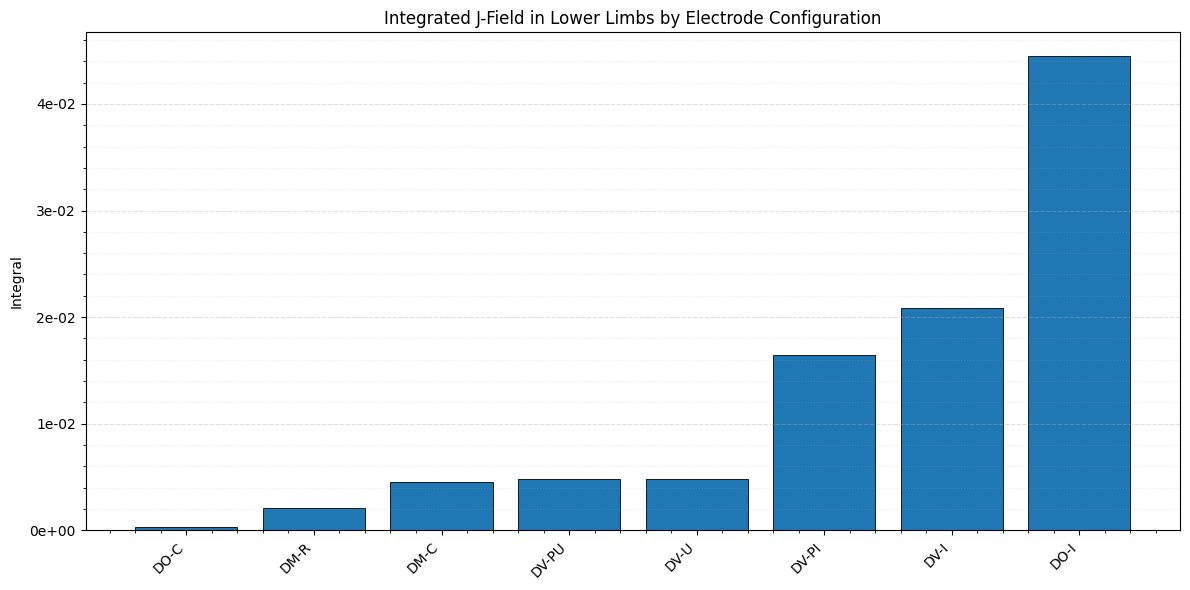

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

def plot_lower_limb_jfield_integrals(
    lower_limb_j_field_dfs: dict[str, pd.DataFrame],
    order: list[str] | None = None,
    integral_col: str = "Integral",
    tissue_col: str = "Tissue",
    expected_tissue_label: str = "Lower Limbs",
    title: str = "Integrated J-Field in Lower Limbs by Electrode Configuration",
    figsize=(12, 6),
    annotate=False,
    sort_ascending_if_no_order=True,
):
    """
    Plot a simple vertical bar chart for lower-limb J-field statistics.

    Assumes each DataFrame contains a single relevant row (typically Tissue == 'Lower Limbs')
    and uses its `Integral` value as the bar height.

    Parameters
    ----------
    lower_limb_j_field_dfs : dict[str, pd.DataFrame]
        Dict of DataFrames keyed by electrode config (e.g., 'DM-C').
    order : list[str] | None
        Optional plotting order. If None, keys are sorted by integral ascending (default).
    integral_col : str
        Column containing integrated values.
    tissue_col : str
        Column containing tissue label (e.g., 'Lower Limbs').
    expected_tissue_label : str
        Preferred tissue row label to use if present.
    title : str
        Plot title.
    figsize : tuple
        Figure size.
    annotate : bool
        If True, annotate each bar with its integral value in scientific notation.
    sort_ascending_if_no_order : bool
        If True and `order` is None, sort bars ascending by integral.
    """

    # Decide initial key order
    keys = order if order is not None else sorted(lower_limb_j_field_dfs.keys())

    # Helper to extract a single integral value from one df
    def _extract_lower_limb_integral(df: pd.DataFrame) -> float:
        if integral_col not in df.columns:
            return np.nan

        df_local = df.copy()
        df_local[integral_col] = pd.to_numeric(df_local[integral_col], errors="coerce")

        # If tissue column exists, prefer the "Lower Limbs" row
        if tissue_col in df_local.columns:
            tissue_clean = df_local[tissue_col].astype(str).str.strip().str.lower()
            match = df_local.loc[tissue_clean == expected_tissue_label.lower(), integral_col]
            if not match.empty:
                return float(match.iloc[0])

        # Fallback: if only one row, use it
        if len(df_local) == 1:
            return float(df_local[integral_col].iloc[0])

        # Fallback: first non-NaN integral
        non_nan = df_local[integral_col].dropna()
        if not non_nan.empty:
            return float(non_nan.iloc[0])

        return np.nan

    # Sort by integral ascending if user didn't provide order
    if order is None and sort_ascending_if_no_order:
        keys = sorted(
            keys,
            key=lambda k: _extract_lower_limb_integral(lower_limb_j_field_dfs[k])
            if k in lower_limb_j_field_dfs else np.inf
        )

    # Collect values
    valid_keys = []
    values = []
    skipped = []

    for key in keys:
        if key not in lower_limb_j_field_dfs:
            skipped.append((key, "missing from lower_limb_j_field_dfs"))
            continue

        df = lower_limb_j_field_dfs[key]

        if integral_col not in df.columns:
            skipped.append((key, f"missing column '{integral_col}'"))
            continue

        val = _extract_lower_limb_integral(df)

        if not np.isfinite(val):
            skipped.append((key, "could not extract a valid lower-limb integral"))
            continue

        valid_keys.append(key)
        values.append(val)

    if len(valid_keys) == 0:
        raise ValueError("No valid lower-limb DataFrames found to plot.")

    # Plot
    x = np.arange(len(valid_keys))
    fig, ax = plt.subplots(figsize=figsize)

    bars = ax.bar(
        x,
        values,
        edgecolor="black",
        linewidth=0.6,
    )

    # Scientific notation on y-axis tick labels (e.g., 4e-04)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0e'))

    if annotate:
        for rect, val in zip(bars, values):
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_height(),
                f"{val:.2e}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=0,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(valid_keys, rotation=45, ha="right")
    ax.set_ylabel("Integral")
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.minorticks_on(); ax.grid(axis="y", which="minor", linestyle=":", alpha=0.25)
    plt.tight_layout()
    plt.show()

    # Diagnostics
    if skipped:
        print("\nSkipped entries:")
        for k, reason in skipped:
            print(f"  - {k}: {reason}")


plot_lower_limb_jfield_integrals(
    lower_limb_j_field_dfs,
    annotate=False,   # set True to print values above bars
)
